# 🚦 Traffic Congestion Prediction

#Submitted by:

 1.Ankita Rani Patro (Roll No: 9)

 2.Ashish Kumar Gupta (Roll No: 15)

In [165]:
#installing reqd libraries
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn joblib

#0. Import Libraries

In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [167]:
sns.set_style("whitegrid")

#1. DATA LOADING

We are using the Metro Interstate Traffic Volume dataset.
It has hourly traffic data from 2012 to 2018 from a highway
in Minnesota, USA. It also has weather info like temperature,
rain, snow etc. which might affect traffic.

In [168]:
#reading the csv file
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')

In [169]:
df.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


holiday: a categorical variable that indicates whether the date is a US national holiday or a regional holiday (such as the Minnesota State Fair).

temp: a numeric variable that shows the average temperature in kelvin.

rain_1h: a numeric variable that shows the amount of rain in mm that occurred in the hour.

snow_1h: a numeric variable that shows the amount of snow in mm that occurred in the hour.

clouds_all: a numeric variable that shows the percentage of cloud cover.

weather_main: a categorical variable that gives a short textual description of the current weather (such as Clear, Clouds, Rain, etc.).

weather_description: a categorical variable that gives a longer textual description of the current weather (such as light rain, overcast clouds, etc.).

date_time: a datetime variable that shows the hour of the data collected in local CST time.

traffic_volume: a numeric variable that shows the hourly I-94 reported westbound traffic volume.

In [170]:
df.shape

(48204, 9)

In [171]:
df['date_time'] = pd.to_datetime(df['date_time'], dayfirst=True)

In [172]:
print("\n Statistical Summary:")
print(df.describe())



 Statistical Summary:
       traffic_volume          temp       rain_1h       snow_1h    clouds_all  \
count    48204.000000  48204.000000  48204.000000  48204.000000  48204.000000   
mean      3259.818355    281.205870      0.334264      0.000222     49.362231   
min          0.000000      0.000000      0.000000      0.000000      0.000000   
25%       1193.000000    272.160000      0.000000      0.000000      1.000000   
50%       3380.000000    282.450000      0.000000      0.000000     64.000000   
75%       4933.000000    291.806000      0.000000      0.000000     90.000000   
max       7280.000000    310.070000   9831.300000      0.510000    100.000000   
std       1986.860670     13.338232     44.789133      0.008168     39.015750   

                           date_time  
count                          48204  
mean   2016-01-05 10:46:16.773711616  
min              2012-10-02 09:00:00  
25%              2014-02-06 11:45:00  
50%              2016-06-11 03:30:00  
75%          

In [173]:
print("\n Dataset Info:")
df.info()



 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   traffic_volume       48204 non-null  int64         
 1   holiday              61 non-null     object        
 2   temp                 48204 non-null  float64       
 3   rain_1h              48204 non-null  float64       
 4   snow_1h              48204 non-null  float64       
 5   clouds_all           48204 non-null  int64         
 6   weather_main         48204 non-null  object        
 7   weather_description  48204 non-null  object        
 8   date_time            48204 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 3.3+ MB


After importing the required libraries, I started by understanding the dataset structure and the type of features available for prediction.

#2. Data Understanding

In [175]:
df.isnull().sum()

,0
traffic_volume,0
holiday,48143
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0


In [176]:
df['holiday'].dropna().unique()

array(['Columbus Day', 'Veterans Day', 'Thanksgiving Day',
       'Christmas Day', 'New Years Day', 'Washingtons Birthday',
       'Memorial Day', 'Independence Day', 'State Fair', 'Labor Day',
       'Martin Luther King Jr Day'], dtype=object)

In [177]:
print("\n Data Types of Each Column:")
print(df.dtypes)


 Data Types of Each Column:
traffic_volume                  int64
holiday                        object
temp                          float64
rain_1h                       float64
snow_1h                       float64
clouds_all                      int64
weather_main                   object
weather_description            object
date_time              datetime64[ns]
dtype: object


In [178]:
print("\n Basic Statistics (numeric columns):")
print(df[['traffic_volume', 'temp', 'rain_1h', 'snow_1h', 'clouds_all']].describe())


 Basic Statistics (numeric columns):
       traffic_volume          temp       rain_1h       snow_1h    clouds_all
count    48204.000000  48204.000000  48204.000000  48204.000000  48204.000000
mean      3259.818355    281.205870      0.334264      0.000222     49.362231
std       1986.860670     13.338232     44.789133      0.008168     39.015750
min          0.000000      0.000000      0.000000      0.000000      0.000000
25%       1193.000000    272.160000      0.000000      0.000000      1.000000
50%       3380.000000    282.450000      0.000000      0.000000     64.000000
75%       4933.000000    291.806000      0.000000      0.000000     90.000000
max       7280.000000    310.070000   9831.300000      0.510000    100.000000


In [179]:
print("\n Weather Category Counts:")
print(df['weather_main'].value_counts())


 Weather Category Counts:
weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5672
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64


In [180]:
print(df['date_time'].min())
print(df['date_time'].max())
print(df.shape[0])

2012-10-02 09:00:00
2018-09-30 23:00:00
48204


I also checked for missing values and data types to ensure the dataset is clean before preprocessing.

#3. Feature Engineering

Here we are creating some extra columns from the existing data.
For example, we noticed that traffic is always high during
morning and evening office hours. So we made an is_peak_hour
column to tell the model about this directly.

Key steps:
  1. Convert 'holiday' NaN → is_holiday (0 or 1)
  2. Convert temp from Kelvin to Celsius
  3. Extract hour, day, month, weekday from date_time
  4. Create is_peak_hour (rush hour flag: 7–9 AM, 4–6 PM)
  5. Create is_weekend flag


In [181]:
# holiday column NaN means normal day
df['is_holiday'] = df['holiday'].apply(lambda x: 0 if pd.isna(x) else 1)
df.drop(columns=['holiday', 'weather_description'], inplace=True)

# temp in kelvin converting to celsius
df['temp_celsius'] = (df['temp'] - 273.15).round(2)

df['is_holiday'].value_counts()

,count
is_holiday,
0,48143
1,61


In [182]:
# extracting time features from the datetime column
df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['weekday'] = df['date_time'].dt.dayofweek  # 0 = monday

df['is_weekend'] = (df['weekday'] >= 5).astype(int)

# peak hours are 7-9am and 4-6pm
df['is_peak_hour'] = df['hour'].apply(lambda h: 1 if (7<=h<=9) or (16<=h<=18) else 0)

df.head()

,traffic_volume,temp,rain_1h,snow_1h,clouds_all,weather_main,date_time,is_holiday,temp_celsius,hour,day,month,weekday,is_weekend,is_peak_hour
0,5545,288.28,0.0,0.0,40,Clouds,2012-10-02 09:00:00,0,15.13,9,2,10,1,0,1
1,4516,289.36,0.0,0.0,75,Clouds,2012-10-02 10:00:00,0,16.21,10,2,10,1,0,0
2,4767,289.58,0.0,0.0,90,Clouds,2012-10-02 11:00:00,0,16.43,11,2,10,1,0,0
3,5026,290.13,0.0,0.0,90,Clouds,2012-10-02 12:00:00,0,16.98,12,2,10,1,0,0
4,4918,291.14,0.0,0.0,75,Clouds,2012-10-02 13:00:00,0,17.99,13,2,10,1,0,0


# 4. Exploratory Data Analysis (EDA)

Now let's explore the data visually.
Graphs help us understand patterns that raw numbers can't show easily.

Plots:
  1. Histogram of traffic volume
  2. Average traffic by hour of day
  3. Correlation heatmap
  4. Average traffic by day of week


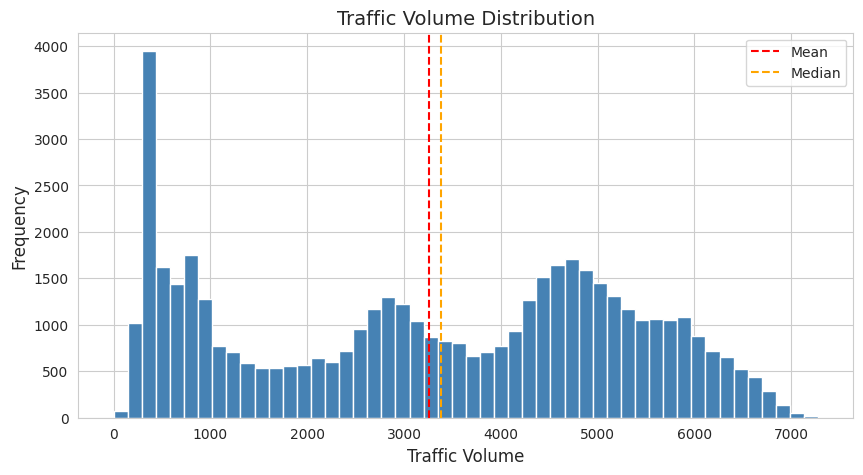

In [183]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['traffic_volume'], bins=50, color='steelblue')
ax.set_title('Traffic Volume Distribution')
ax.set_xlabel('Traffic Volume')
ax.set_ylabel('Frequency')
ax.axvline(df['traffic_volume'].mean(), color='red', linestyle='--', label='Mean')
ax.axvline(df['traffic_volume'].median(), color='orange', linestyle='--', label='Median')
ax.legend()
plt.savefig('plot1_histogram.png', dpi=150)
plt.show()

The distribution is bimodal (two humps).

One peak around low traffic (night hours) and one around high traffic (daytime).

The mean (~3200) is pulled up by heavy rush-hour traffic.

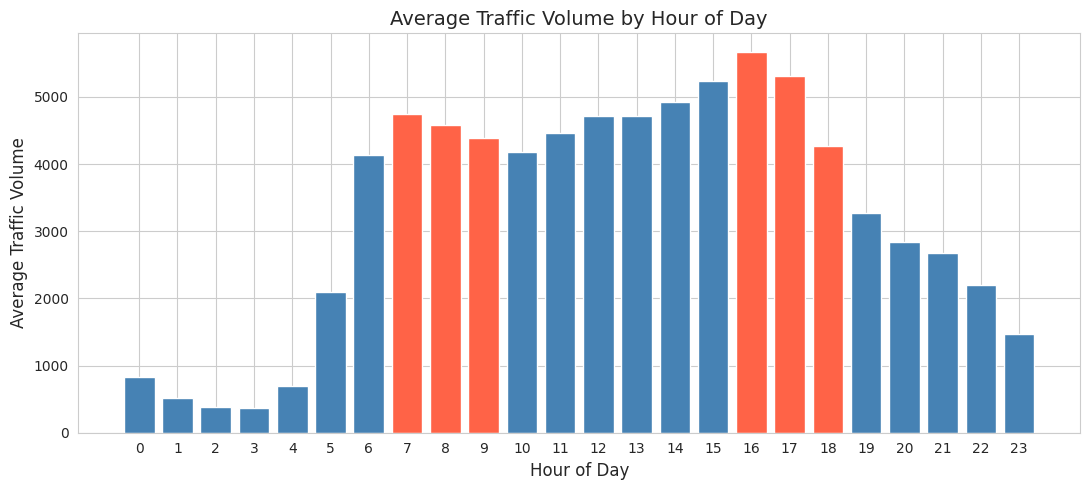

In [185]:
hourly_avg = df.groupby('hour')['traffic_volume'].mean()

colors = ['tomato' if (7<=h<=9 or 16<=h<=18) else 'steelblue' for h in hourly_avg.index]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(hourly_avg.index, hourly_avg.values, color=colors)
ax.set_title('Average Traffic Volume by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Traffic Volume')
ax.set_xticks(range(24))
plt.tight_layout()
plt.savefig('plot2_traffic_by_hour.png', dpi=150)
plt.show()

Clear morning rush (7 to 9 AM) and evening rush (4 to 6 PM) peaks visible.

Traffic drops significantly after 8 PM and is lowest between 1 to 4 AM.

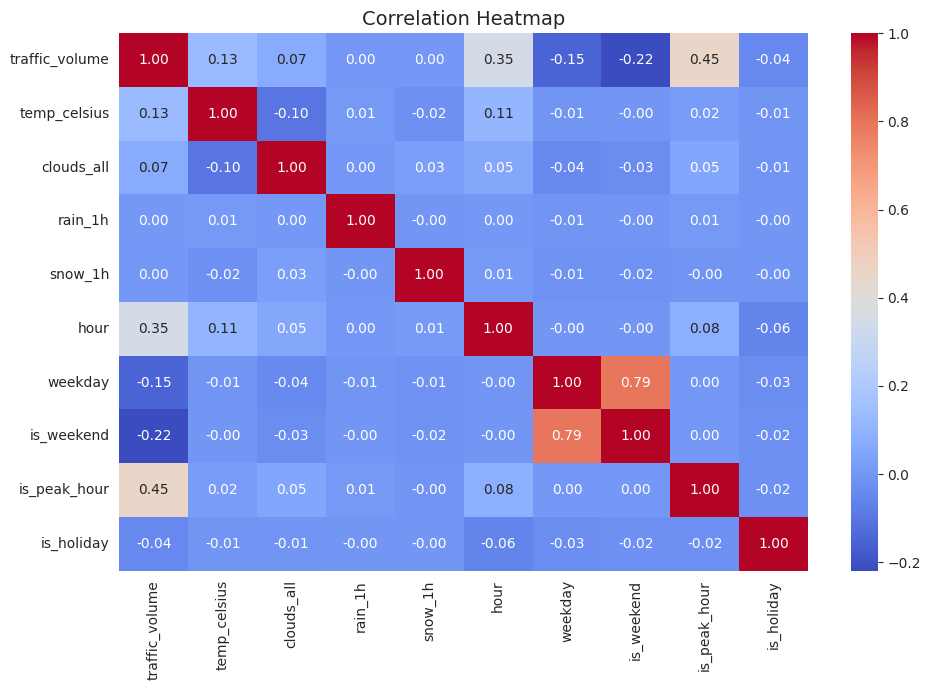

In [186]:
numeric_cols = ['traffic_volume', 'temp_celsius', 'clouds_all', 'rain_1h',
                'snow_1h', 'hour', 'weekday', 'is_weekend', 'is_peak_hour', 'is_holiday']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plot3_correlation_heatmap.png', dpi=150)
plt.show()

is_peak_hour' and 'hour' have the strongest correlation with traffic volume.
   
Temperature has a moderate positive correlation (more traffic in warmer months).
   
'is_weekend' shows negative correlation — less traffic on weekends.



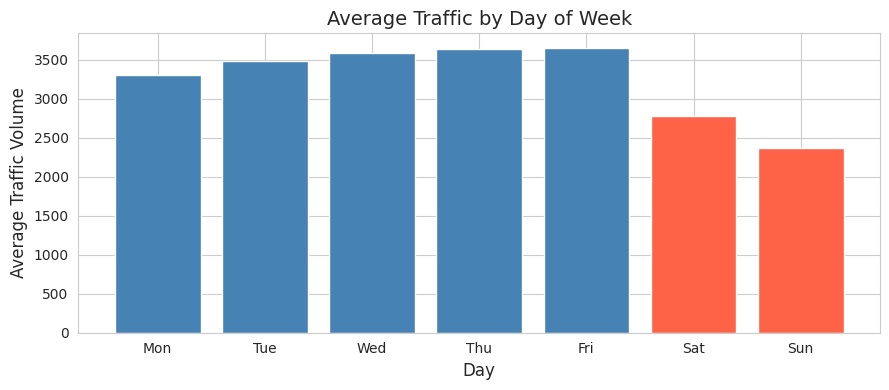

In [187]:
weekday_avg = df.groupby('weekday')['traffic_volume'].mean()
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

colors = ['steelblue'] * 5 + ['tomato'] * 2

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(day_labels, weekday_avg.values, color=colors)
ax.set_title('Average Traffic by Day of Week')
ax.set_xlabel('Day')
ax.set_ylabel('Average Traffic Volume')
plt.tight_layout()
plt.savefig('plot4_traffic_by_weekday.png', dpi=150)
plt.show()

Traffic on Saturday and Sunday is noticeably less than
weekdays. Friday has the highest traffic which is
interesting - maybe people travel more on Fridays.

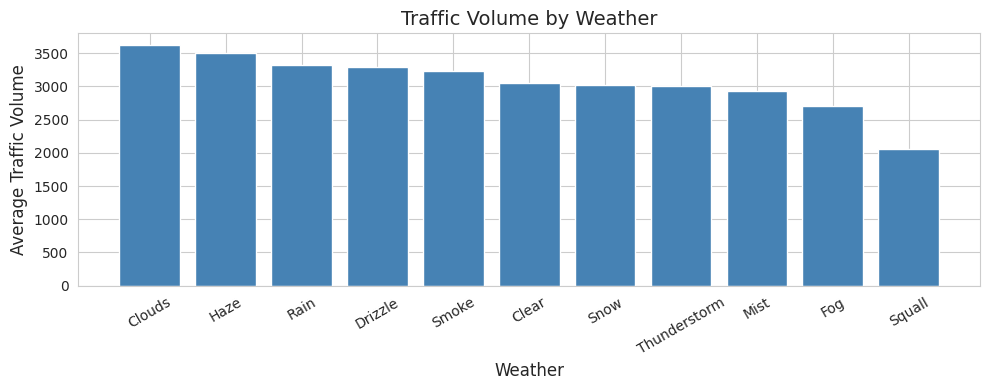

In [188]:
weather_avg = df.groupby('weather_main')['traffic_volume'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(weather_avg.index, weather_avg.values, color='steelblue')
ax.set_title('Traffic Volume by Weather')
ax.set_xlabel('Weather')
ax.set_ylabel('Average Traffic Volume')
ax.set_xticks(range(len(weather_avg.index)))
ax.set_xticklabels(weather_avg.index, rotation=30)
plt.tight_layout()
plt.savefig('plot4b_traffic_by_weather.png', dpi=150)
plt.show()

I thought Clear weather would have the highest traffic but
Clouds came first. I think this is because cloudy weather
is more common during daytime in Minnesota when people are
already commuting. So weather is not really the main reason
for traffic - time of day is more important as we saw in the
hourly graph.

#5. Data Preprocessing

Here we prepare the data for the model. We need to convert
text columns to numbers and scale everything to the same range.

In [189]:
# checking if any nulls remain after feature engineering
print(df.isnull().sum())


traffic_volume    0
temp              0
rain_1h           0
snow_1h           0
clouds_all        0
weather_main      0
date_time         0
is_holiday        0
temp_celsius      0
hour              0
day               0
month             0
weekday           0
is_weekend        0
is_peak_hour      0
dtype: int64


No missing values in numeric columns

In [191]:
# weather_main is text so we need to convert it to numbers
# using label encoder for this
le = LabelEncoder()
df['weather_encoded'] = le.fit_transform(df['weather_main'])

print(le.classes_)

['Clear' 'Clouds' 'Drizzle' 'Fog' 'Haze' 'Mist' 'Rain' 'Smoke' 'Snow'
 'Squall' 'Thunderstorm']


In [192]:
feature_cols = ['hour', 'day', 'month', 'weekday', 'is_weekend',
                'is_peak_hour', 'is_holiday', 'temp_celsius',
                'clouds_all', 'rain_1h', 'snow_1h', 'weather_encoded']

X = df[feature_cols].copy()
y = df['traffic_volume'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (48204, 12)
y shape: (48204,)


In [193]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

I performed preprocessing to clean the dataset and convert categorical values into numerical format, as machine learning models cannot handle text data directly

#6. Target Enginnering

Creating Traffic Level Labels

We divided traffic volume into 3 categories using quantiles:
Low, Medium and High. This helps us understand congestion
severity even though our models predict the exact number

In [194]:
q33 = df['traffic_volume'].quantile(0.33)
q67 = df['traffic_volume'].quantile(0.67)

In [195]:
print(q33, q67)

2157.9900000000016 4586.0


In [196]:
def label_traffic(v):
    if v <= q33:
        return 'Low'
    elif v <= q67:
        return 'Medium'
    else:
        return 'High'

In [197]:
df['traffic_level'] = df['traffic_volume'].apply(label_traffic)

In [198]:
df['traffic_level'].value_counts()

,count
traffic_level,
Medium,16395
Low,15907
High,15902


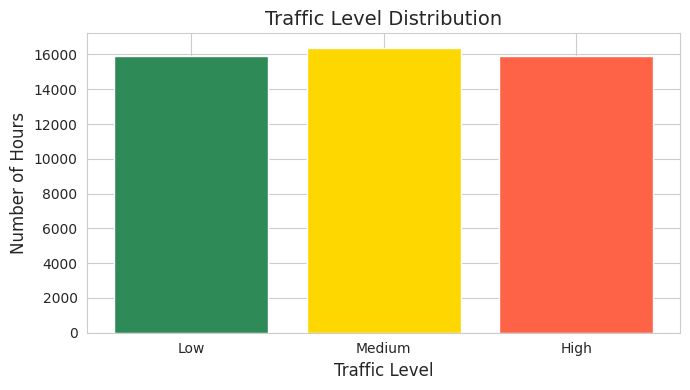

In [199]:
counts = df['traffic_level'].value_counts()[['Low', 'Medium', 'High']]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.index, counts.values, color=['seagreen', 'gold', 'tomato'])
ax.set_title('Traffic Level Distribution')
ax.set_xlabel('Traffic Level')
ax.set_ylabel('Number of Hours')
plt.tight_layout()
plt.savefig('plot5_traffic_level_dist.png', dpi=150)
plt.show()


#7. Train Test Split

We split data into:
  - Training set (80%)
  - Testing set  (20%)


In [200]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [201]:
print(f"Training: {X_train.shape[0]} samples")
print(f"Testing: {X_test.shape[0]} samples")

Training: 38563 samples
Testing: 9641 samples


#8. ML Models

We train two models:

  A. Linear Regression  — Simple baseline model

  B. Random Forest      — Powerful tree-based ensemble model


In [202]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

In [203]:
#Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

results_lr = evaluate_model("Linear Regression", y_test, y_pred_lr)
print("  Linear Regression done")

Linear Regression -> MAE: 1364.40, RMSE: 1578.57, R2: 0.3697
  Linear Regression done


Initially, I tried using Linear Regression, but the performance was not very good because traffic patterns are non-linear.

In [204]:
#Random Forest
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

results_rf = evaluate_model("Random Forest", y_test, y_pred_rf)
print("Random Forest done")

Random Forest -> MAE: 261.17, RMSE: 457.88, R2: 0.9470
Random Forest done


I selected Random Forest because it can handle non-linear relationships and performs well on structured datasets.

#9. Model Evaluation

Lower MAE and RMSE = better (fewer prediction errors).

Higher R² (closer to 1.0) = better (explains more variance).

In [205]:
results_df = pd.DataFrame([results_lr, results_rf]).set_index('Model')

In [207]:
#Comparison of Models
results_df.round(2)

,MAE,RMSE,R2
Model,,,
Linear Regression,1364.40,1578.57,0.37
Random Forest,261.17,457.88,0.95


In [208]:
best_model_name = results_df['R2'].idxmax()
print("Best model:", best_model_name)

Best model: Random Forest


Compared to Linear Regression, Random Forest performed better as it can capture complex patterns in the data.

However, in real-world scenarios, performance may vary due to unpredictable factors such as sudden traffic jams or weather changes.

#10. Visualizations

Three key plots:
  1. Prediction vs Actual  — Are predictions close to real values?
  2. Feature Importance    — Which features matter most? (Random Forest)
  3. Residual Plot         — Are errors random or patterned?

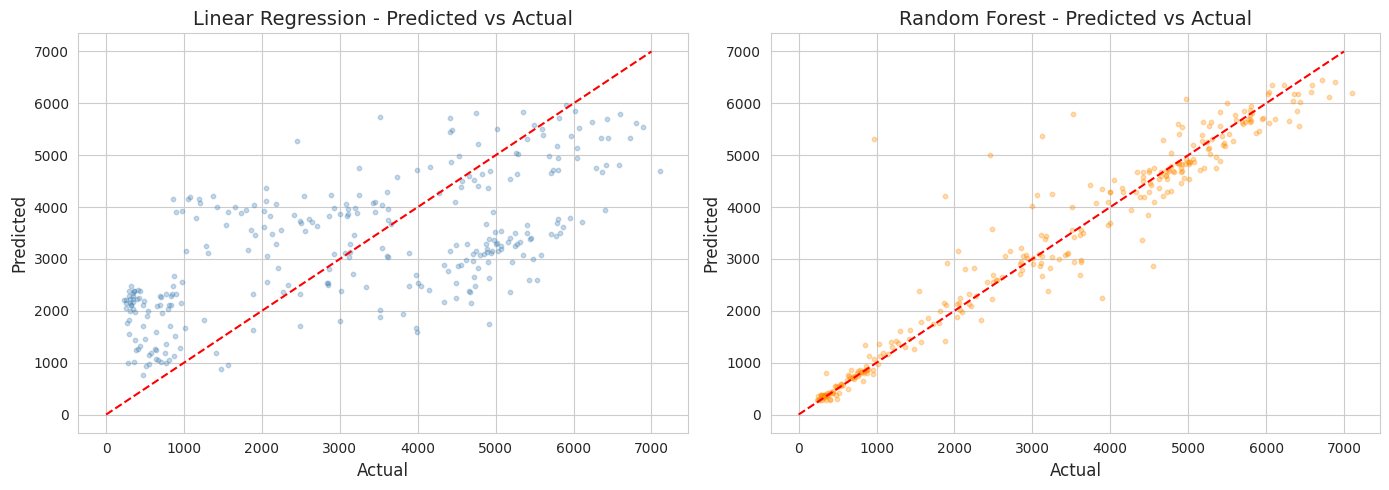

In [209]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# linear regression
axes[0].scatter(y_test[:300], y_pred_lr[:300], alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 7000], [0, 7000], 'r--')
axes[0].set_title('Linear Regression - Predicted vs Actual')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

# random forest
axes[1].scatter(y_test[:300], y_pred_rf[:300], alpha=0.3, s=10, color='darkorange')
axes[1].plot([0, 7000], [0, 7000], 'r--')
axes[1].set_title('Random Forest - Predicted vs Actual')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.savefig('plot6_pred_vs_actual.png', dpi=150)
plt.show()

Dots on the red line = perfect prediction.

Random Forest dots are closer to the line → better accuracy


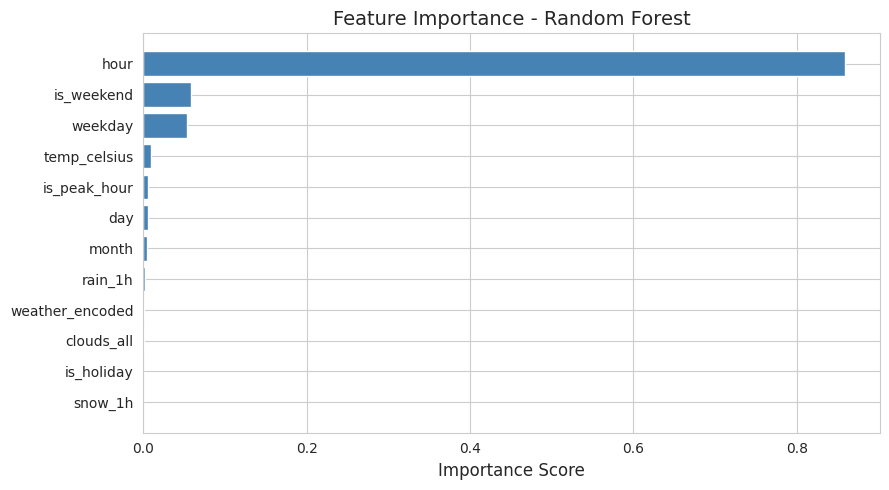

In [210]:
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='steelblue')
ax.set_title('Feature Importance - Random Forest')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot7_feature_importance.png', dpi=150)
plt.show()

'hour' is the most important feature — traffic is highly time-dependent.

'is_peak_hour' and 'weekday' also rank high — our feature engineering helped.


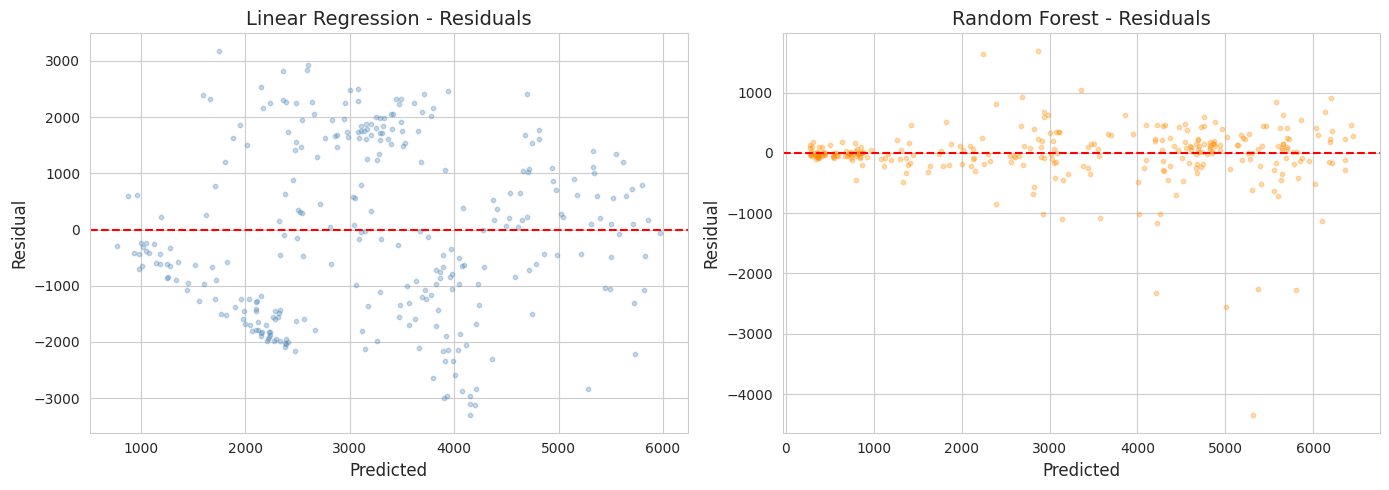

In [211]:
residuals_lr = np.array(y_test) - y_pred_lr
residuals_rf = np.array(y_test) - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# linear regression residuals
axes[0].scatter(y_pred_lr[:300], residuals_lr[:300], alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Linear Regression - Residuals')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')

# random forest residuals
axes[1].scatter(y_pred_rf[:300], residuals_rf[:300], alpha=0.3, s=10, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Random Forest - Residuals')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.savefig('plot8_residuals.png', dpi=150)
plt.show()

Random Forest residuals are scattered close to zero which is
good. Linear Regression residuals are spread very wide showing
large errors. Ideally residuals should be randomly scattered
around zero with no pattern.

#11. Deep Learning-LSTM

We used LSTM because traffic data is a time series.
What happened in the past 24 hours affects the next hour.
Normal ML models don't consider this order of data but
LSTM has memory so it can learn from past sequences.
We look back 24 hours to predict the next hour.

In [212]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print(tf.__version__)

2.20.0


In [215]:
#Scaling traffic volume for LSTM
lstm_scaler=MinMaxScaler()
traffic_scaled=lstm_scaler.fit_transform(df[['traffic_volume']].values)

In [216]:
#Create sequences
SEQ_LEN = 24  #24 hours lookback

def create_sequences(data, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_len):
        X_seq.append(data[i : i + seq_len, 0])
        y_seq.append(data[i + seq_len, 0])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(traffic_scaled, SEQ_LEN)

In [217]:
#Reshaping for LSTM input: (samples, timesteps, features=1)
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

In [218]:
print(X_seq.shape)
print(y_seq.shape)

(48180, 24, 1)
(48180,)


In [219]:
#Splitting sequences
split_idx = int(0.8 * len(X_seq))
X_train_seq, X_test_seq = X_seq[:split_idx], X_seq[split_idx:]
y_train_seq, y_test_seq = y_seq[:split_idx], y_seq[split_idx:]

print(X_train_seq.shape, X_test_seq.shape)

(38544, 24, 1) (9636, 24, 1)


#12. LSTM Evaluation

Evaluated using the same metrics as ML models:

  - MAE  : Average prediction error in vehicles/hour
  - RMSE : Penalises larger errors more heavily

Also we plot training vs validation loss to check learning progress.

In [220]:
tf.random.set_seed(42)

# building the lstm model
lstm_model = Sequential()
lstm_model.add(LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(32, return_sequences=False))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(16, activation='relu'))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [221]:
# training the model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - loss: 0.0462 - mae: 0.1671 - val_loss: 0.0132 - val_mae: 0.0925
Epoch 2/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - loss: 0.0155 - mae: 0.0923 - val_loss: 0.0062 - val_mae: 0.0590
Epoch 3/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - loss: 0.0114 - mae: 0.0765 - val_loss: 0.0057 - val_mae: 0.0580
Epoch 4/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - loss: 0.0101 - mae: 0.0710 - val_loss: 0.0064 - val_mae: 0.0628
Epoch 5/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - loss: 0.0094 - mae: 0.0681 - val_loss: 0.0054 - val_mae: 0.0560
Epoch 6/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 20s 61ms/step - loss: 0.0088 - mae: 0.0660 - val_loss: 0.0068 - val_mae: 0.0662
Epoch 7/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - loss: 0.0086 - mae: 0.0652 - val_loss: 0.0049 - val_mae: 0.0522
Epoch 8/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - loss: 0.0083 - mae: 0.0632 - val_loss: 0.0053 - val_mae: 0.0555
Epoch 9/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 

In [223]:
print("Best epoch:", early_stop.best_epoch + 1)
print("Total epochs trained:", len(history.history['loss']))

Best epoch: 28
Total epochs trained: 30


In [222]:
# predicting on test data
y_pred_lstm_scaled = lstm_model.predict(X_test_seq)
y_pred_lstm = lstm_scaler.inverse_transform(y_pred_lstm_scaled).flatten()
y_actual_lstm = lstm_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

302/302 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step


In [224]:
results_lstm = evaluate_model("LSTM", y_actual_lstm, y_pred_lstm)

LSTM -> MAE: 299.50, RMSE: 419.75, R2: 0.9545


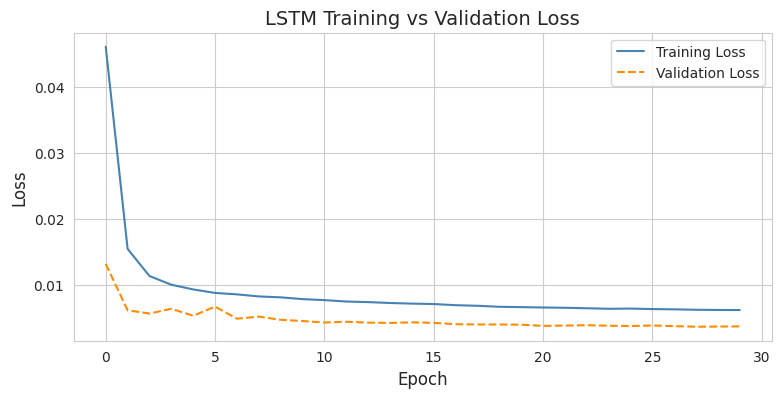

In [226]:
#Training Loss plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history.history['loss'], label='Training Loss', color='steelblue')
ax.plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linestyle='--')
ax.set_title('LSTM Training vs Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.savefig('plot9_lstm_loss.png', dpi=150)
plt.show()

Both lines decreasing → model is learning correctly.

If validation loss levels off → early stopping triggered (prevents overfitting).


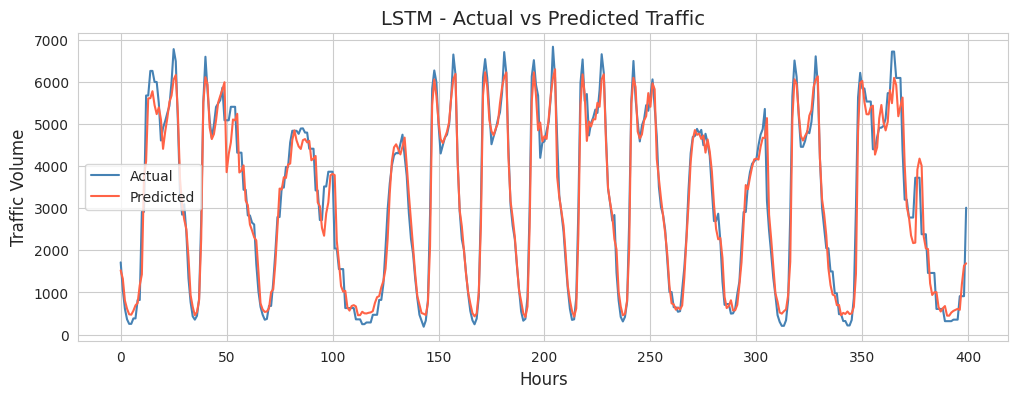

In [227]:
#LSTM Prediction vs Actual
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_actual_lstm[:400], label='Actual', color='steelblue')
ax.plot(y_pred_lstm[:400], label='Predicted', color='tomato')
ax.set_title('LSTM - Actual vs Predicted Traffic')
ax.set_xlabel('Hours')
ax.set_ylabel('Traffic Volume')
ax.legend()
plt.savefig('plot10_lstm_pred_vs_actual.png', dpi=150)
plt.show()

#13. Final Model Comparison

In [237]:
results_lr   = evaluate_model("Linear Regression", y_test, y_pred_lr)
results_rf   = evaluate_model("Random Forest", y_test, y_pred_rf)
results_lstm = evaluate_model("LSTM", y_actual_lstm, y_pred_lstm)

all_results = pd.DataFrame([results_lr, results_rf, results_lstm]).set_index('Model').round(4)
all_results

Linear Regression -> MAE: 1364.40, RMSE: 1578.57, R2: 0.3697
Random Forest -> MAE: 261.17, RMSE: 457.88, R2: 0.9470
LSTM -> MAE: 299.50, RMSE: 419.75, R2: 0.9545


,MAE,RMSE,R2
Model,,,
Linear Regression,1364.3969,1578.5651,0.3697
Random Forest,261.1718,457.8805,0.9470
LSTM,299.4997,419.7508,0.9545


  We observed that:
  LSTM is the best model

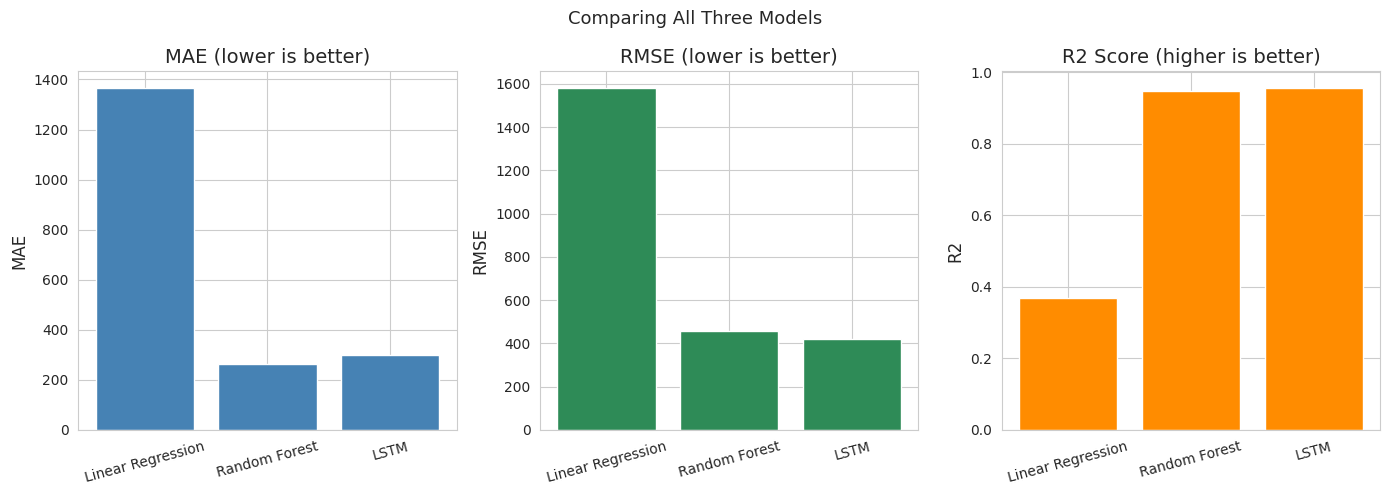

In [238]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# MAE - lower is better
axes[0].bar(all_results.index, all_results['MAE'], color='steelblue')
axes[0].set_title('MAE (lower is better)')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=15)

# RMSE - lower is better
axes[1].bar(all_results.index, all_results['RMSE'], color='seagreen')
axes[1].set_title('RMSE (lower is better)')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)

# R2 score - higher is better
axes[2].bar(all_results.index, all_results['R2'], color='darkorange')
axes[2].set_title('R2 Score (higher is better)')
axes[2].set_ylabel('R2')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Comparing All Three Models', fontsize=13)
plt.tight_layout()
plt.savefig('plot11_model_comparison.png', dpi=150)
plt.show()

#14. Real Prediction Function

A ready-to-use function that takes real-world inputs and
predicts both the exact traffic volume and the level (Low/Medium/High).

In [239]:
def predict_traffic(hour, month, weekday, temp_celsius, weather,
                    is_holiday=0, clouds_pct=30, rain=0.0, snow=0.0):

    is_weekend = 1 if weekday >= 5 else 0
    is_peak = 1 if (7 <= hour <= 9) or (16 <= hour <= 18) else 0
    day_sample = 15

    if weather in le.classes_:
        weather_enc = le.transform([weather])[0]
    else:
        weather_enc = le.transform(['Clouds'])[0]

    sample = np.array([[hour, day_sample, month, weekday, is_weekend,
                        is_peak, is_holiday, temp_celsius, clouds_pct,
                        rain, snow, weather_enc]])

    sample_scaled = scaler.transform(sample)
    predicted_volume = max(0, rf_model.predict(sample_scaled)[0])

    if predicted_volume <= q33:
        level = 'Low'
    elif predicted_volume <= q67:
        level = 'Medium'
    else:
        level = 'High'

    print(f"Predicted Volume: {round(predicted_volume)} vehicles/hour")
    print(f"Traffic Level: {level}")
    print(f"Peak Hour: {'Yes' if is_peak else 'No'}")

let's test the model with some inputs


In [240]:
predict_traffic(hour=8, month=3, weekday=0, temp_celsius=10, weather='Clear')

Predicted Volume: 5656 vehicles/hour
Traffic Level: High
Peak Hour: Yes


In [241]:
predict_traffic(hour=17, month=6, weekday=2, temp_celsius=20, weather='Rain', rain=3.5)

Predicted Volume: 6046 vehicles/hour
Traffic Level: High
Peak Hour: Yes


In [242]:
predict_traffic(hour=2, month=1, weekday=6, temp_celsius=-5, weather='Snow', is_holiday=1)

Predicted Volume: 550 vehicles/hour
Traffic Level: Low
Peak Hour: No


In [243]:
predict_traffic(hour=14, month=5, weekday=1, temp_celsius=18, weather='Clouds')

Predicted Volume: 5158 vehicles/hour
Traffic Level: High
Peak Hour: No


In [244]:
predict_traffic(hour=8, month=7, weekday=3, temp_celsius=28, weather='Thunderstorm', rain=8.0)

Predicted Volume: 4344 vehicles/hour
Traffic Level: Medium
Peak Hour: Yes


# Conclusion


We worked on predicting traffic congestion using the Metro Interstate Traffic Volume dataset which has around 48000 rows
of real hourly highway data.


We implemented and compared three models — Linear Regression, Random Forest, and LSTM (Long Short-Term Memory).

Linear Regression gave very bad results with R2 = 0.37. This is because traffic patterns are not linear at all so this model was not suitable for this problem.


Both LSTM and Random Forest got nearly equal R2 score where Random forest

"R2 score=0.9470"

and that of LSTM

"R2 score=0.9545".
But when we look at other metrics they are different.
LSTM has lower RMSE which means it handles large traffic spikes better. Random Forest has lower MAE which means its average prediction error is smaller.

If we want to
reduce large errors LSTM is better. If we want overall
average accuracy Random Forest is better.



 For a real
traffic system reducing large errors is more important
so we prefer LSTM.

This project taught us that choosing the right model for the right problem is very important.

We initially thought Random Forest would win but LSTM performed better because
traffic follows a time pattern. The feature engineering part was the most interesting that is creating is_peak_hour from
raw datetime made a big difference in model accuracy.